<a href="https://colab.research.google.com/github/Dramy8/DI_Bootcamp/blob/main/Week08/Day5/Daily/Breast_Cancer_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Daily Challenge: Breast Cancer Prediction


👩‍🏫 👩🏿‍🏫 What You’ll learn
Data visualization with scatter plots.
Basic understanding of classification models
Interpreting the results.


🛠️ What you will create
In this notebook, you will be using 4 classification models- Logistic Regression, K Nearest Neighbours, Random Forests and Support Vector Machines (SVM).
dataset available here



Your Task
Exploratory Data Analysis
Use pandas to load the dataset and examine the first few rows.
Check and handle the missing values.
Drop any unnecessary column
Create a Countplot to display diagnosis from magma

Data Preprocessing, Building Models and Evaluation :
counts of unique rows in the ‘diagnosis’ column
map categorical values to numerical values
Splitting the data into train and test
Implement logistic regression and print the accuracy.
Implement K Nearest Neighbours and print the accuracy.
Implement Random Forests and print the accuracy.
Implement Support Vector Machines (SVM) and print the accuracy.
Which is the best model ?



In [19]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:

ZIP_PATH = 'archive.zip'  # or your path
EXTRACT_DIR = 'breast_cancer'

zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)
csv_files = glob.glob(EXTRACT_DIR + "/*.csv")
print(csv_files)

# TODO: list CSV files under EXTRACT_DIR
csv_path = csv_files[0]
  # set to the CSV you choose

# TODO: load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)
df


['breast_cancer/data.csv']


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [4]:
df.columns = df.columns.str.strip()

In [7]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [8]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [10]:
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

In [11]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [12]:
df = df.drop(columns='Unnamed: 32')

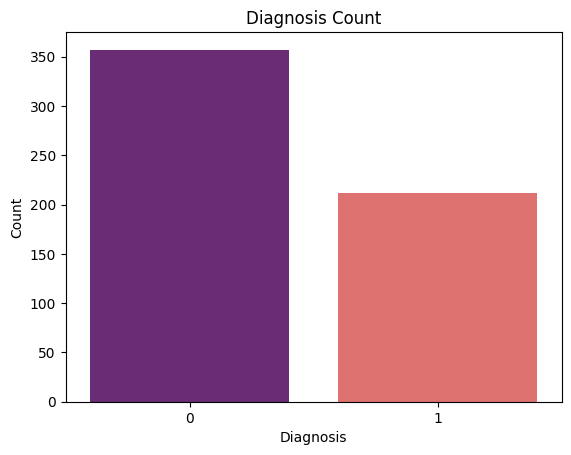

In [21]:
sns.countplot(
    data=df,
    x='diagnosis',
    hue='diagnosis',
    palette='magma',
    legend=False
)

plt.title('Diagnosis Count')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [22]:
df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


In [23]:
df['diagnosis'].value_counts(normalize=True) * 100

,proportion
diagnosis,
0,62.741652
1,37.258348


In [25]:
target = 'diagnosis'

X = df.drop(columns=[target,'id'])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

Preprocessing pipeline

In [26]:
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ]
)

Helper - evaluation function

In [27]:
def eval_and_report(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }

    print(name, metrics)

    cm = confusion_matrix(y_test, y_pred)

    plt.imshow(cm)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.colorbar()
    plt.show()

    return metrics

Logistic Regression

Logistic Regression {'accuracy': 0.9736842105263158, 'precision': 0.975609756097561, 'recall': 0.9523809523809523, 'f1': 0.963855421686747}


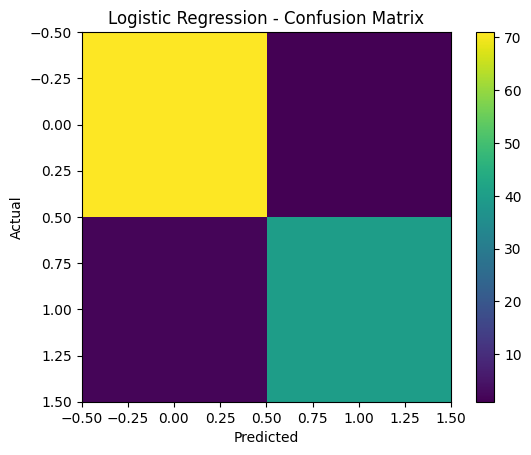

In [30]:
pipe_lr = Pipeline([
    ('preprocessor', pre),
    ('model', LogisticRegression(
        solver='liblinear',
        max_iter=1000
    ))
])

pipe_lr.fit(X_train, y_train)

lr_metrics = eval_and_report('Logistic Regression', pipe_lr, X_test, y_test)

In [31]:
print("Accuracy:", lr_metrics['accuracy'])

Accuracy: 0.9736842105263158


K Nearest Neighbours

KNN {'accuracy': 0.956140350877193, 'precision': 0.9743589743589743, 'recall': 0.9047619047619048, 'f1': 0.9382716049382716}


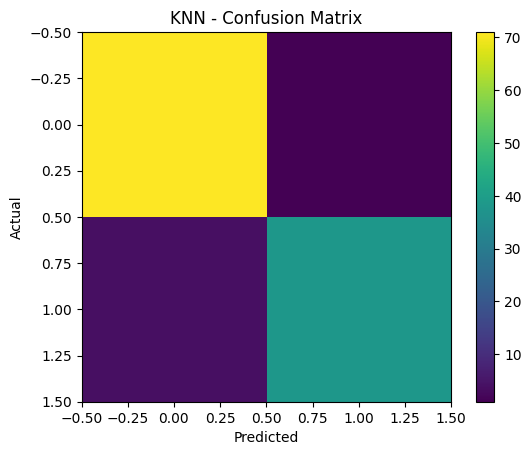

In [32]:
from sklearn.neighbors import KNeighborsClassifier

pipe_knn = Pipeline([
    ('preprocessor', pre),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_knn.fit(X_train, y_train)
knn_metrics = eval_and_report('KNN', pipe_knn, X_test, y_test)

In [33]:
print("Accuracy:", knn_metrics['accuracy'])

Accuracy: 0.956140350877193


Random Forests

Random Forest {'accuracy': 0.9736842105263158, 'precision': 1.0, 'recall': 0.9285714285714286, 'f1': 0.9629629629629629}


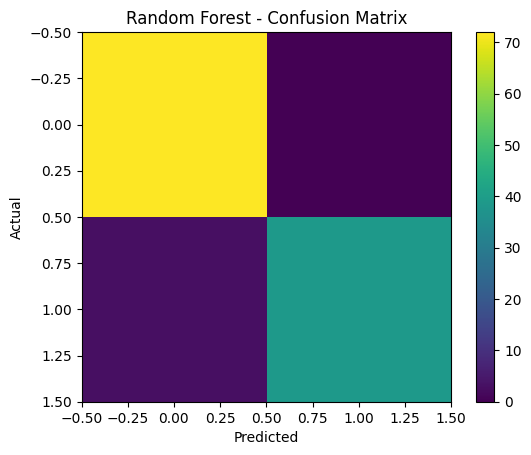

In [34]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('preprocessor', pre),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE
    ))
])

pipe_rf.fit(X_train, y_train)
rf_metrics = eval_and_report('Random Forest', pipe_rf, X_test, y_test)

In [35]:
print("Accuracy:", rf_metrics['accuracy'])

Accuracy: 0.9736842105263158


SVM no grid {'accuracy': 0.9736842105263158, 'precision': 1.0, 'recall': 0.9285714285714286, 'f1': 0.9629629629629629}


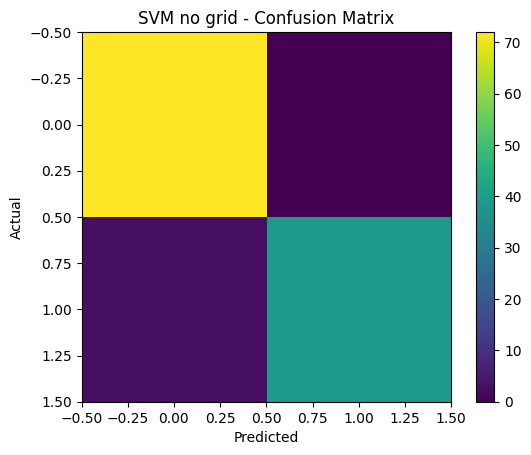

In [38]:
pipe_svm = Pipeline([
    ('preprocessor', pre),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

pipe_svm.fit(X_train, y_train)

svm_metrics = eval_and_report(
    'SVM no grid',
    pipe_svm,
    X_test,
    y_test
)

In [39]:
print("Accuracy:", svm_metrics['accuracy'])

Accuracy: 0.9736842105263158


Which is the best model ?

In [40]:
summary = {
    'Logistic Regression': lr_metrics,
    'KNN': knn_metrics,
    'Random Forest': rf_metrics,
    'SVM': svm_metrics
}

summary_df = pd.DataFrame.from_dict(summary, orient='index')
summary_df

,accuracy,precision,recall,f1
Logistic Regression,0.973684,0.975610,0.952381,0.963855
KNN,0.956140,0.974359,0.904762,0.938272
Random Forest,0.973684,1.000000,0.928571,0.962963
SVM,0.973684,1.000000,0.928571,0.962963


In [41]:
summary_df.sort_values(by='recall', ascending=False)

,accuracy,precision,recall,f1
Logistic Regression,0.973684,0.975610,0.952381,0.963855
Random Forest,0.973684,1.000000,0.928571,0.962963
SVM,0.973684,1.000000,0.928571,0.962963
KNN,0.956140,0.974359,0.904762,0.938272


The best model seems to be the Logistic Regression.